# Pre-requisites

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
#! pip install torch torchvision --index-url https://download.pytorch.org/whl/cu130
#! pip install transformers tqdm boto3 requests regex sentencepiece sacremoses ipywidgets pandas matplotlib seaborn scikit-learn nltk --quiet

Looking in indexes: https://download.pytorch.org/whl/cu130


In [ ]:
import os
#os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import re
from transformers import BertTokenizer, BertForSequenceClassification
from sklearn.model_selection import train_test_split

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Using {device}")


 Using cuda


## Seed

In [ ]:
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Task 1: Acquire and pre-process the Web of Science Dataset

## Load data

In [ ]:
DATA_DIR = "WOS11967"
GLOVE_PATH = "glove.6B.300d.txt"
FIGURES_DIR = "figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

X_PATH = os.path.join(DATA_DIR, "X.txt")
YL1_PATH = os.path.join(DATA_DIR, "YL1.txt")
YL2_PATH = os.path.join(DATA_DIR, "YL2.txt")

with open(X_PATH, 'r', encoding='utf-8') as f:
    raw_texts = f.readlines()
with open(YL1_PATH, 'r', encoding='utf-8') as f:
    raw_labels_l1 = [int(line.strip()) for line in f.readlines()]
with open(YL2_PATH, 'r', encoding='utf-8') as f:
    raw_labels_l2 = [int(line.strip()) for line in f.readlines()]


print(f"{len(raw_texts)} texts")
print(f"Level 1: {len(raw_labels_l1)} labels, {len(set(raw_labels_l1))} classes")
print(f"Level 2: {len(raw_labels_l2)} labels, {len(set(raw_labels_l2))} classes")


11967 texts
Level 1: 11967 labels, 7 classes
Level 2: 11967 labels, 5 classes


## Preprocess data

### Exploratory Analysis

In [ ]:
def create_global_l2_labels(l1_labels, l2_labels):
    """
    Combines L1 (Parent) and L2 (Local Child) to create unique Global L2 IDs to fix Y.txt bug.
    """
    # Create unique string pairs for each (L1, L2) combination
    combined_labels = [f"{p}-{c}" for p, c in zip(l1_labels, l2_labels)]

    unique_combinations = sorted(list(set(combined_labels)))
    mapping = {label: idx for idx, label in enumerate(unique_combinations)}

    global_l2_labels = [mapping[label] for label in combined_labels]

    print(f"Found {len(unique_combinations)} unique sub-fields (Level 2 classes).")
    return global_l2_labels

raw_labels_l2 = create_global_l2_labels(raw_labels_l1, raw_labels_l2)
print(f"Level 2: {len(raw_labels_l2)} labels, {len(set(raw_labels_l2))} classes")
OUTPUT_DIM_L2 = len(set(raw_labels_l2))

Found 34 unique sub-fields (Level 2 classes).
Level 2: 11967 labels, 34 classes


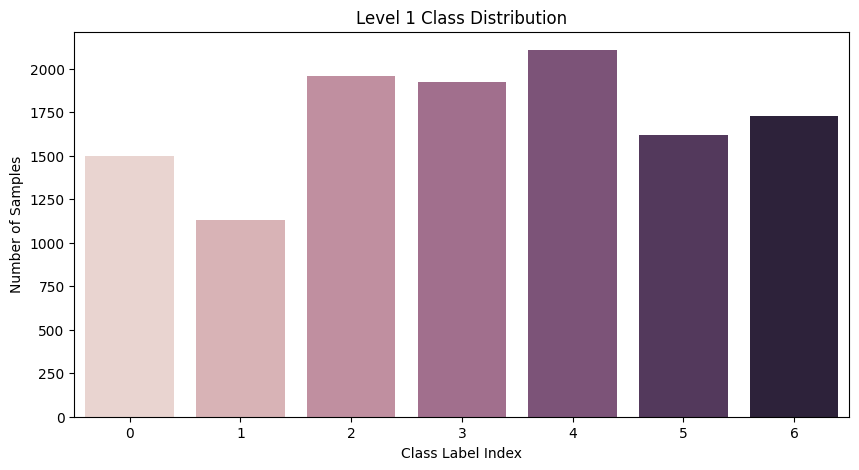

Level 1 Class Distribution Counts:
Most common class: (4, 2107)
Least common class: (1, 1132)


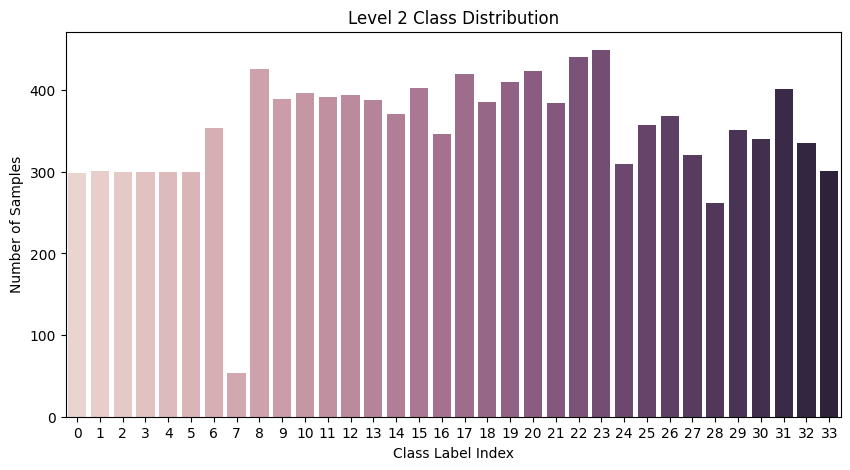

Level 2 Class Distribution Counts:
Most common class: (23, 449)
Least common class: (7, 53)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

def plot_class_distribution(labels, title):
    counts = Counter(labels)

    class_indices = sorted(counts.keys())
    frequencies = [counts[i] for i in class_indices]

    plt.figure(figsize=(10, 5))
    sns.barplot(x=class_indices, y=frequencies, hue=class_indices, legend=False)
    plt.title(title)
    plt.xlabel('Class Label Index')
    plt.ylabel('Number of Samples')
    plt.show()

    print(f"{title} Counts:")
    print(f"Most common class: {counts.most_common(1)[0]}")
    print(f"Least common class: {counts.most_common()[-1]}")

plot_class_distribution(raw_labels_l1, "Level 1 Class Distribution")
plot_class_distribution(raw_labels_l2, "Level 2 Class Distribution")

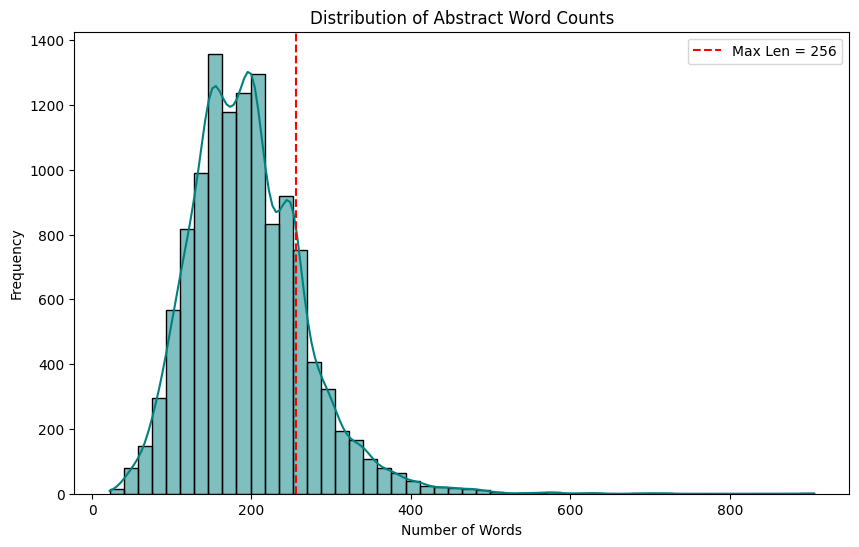

Average Length: 195.17
Max Length: 906
Percentage of abstracts <= 256 words: 83.71%


In [ ]:
def plot_sequence_lengths(texts):
    # Calculate length of each abstract (by number of words)
    seq_lengths = [len(text.split()) for text in texts]

    plt.figure(figsize=(10, 6))
    sns.histplot(seq_lengths, bins=50, kde=True, color='teal')
    plt.title('Distribution of Abstract Word Counts')
    plt.xlabel('Number of Words')
    plt.ylabel('Frequency')

    plt.axvline(x=256, color='red', linestyle='--', label='Max Len = 256')
    plt.legend()
    plt.show()

    print(f"Average Length: {np.mean(seq_lengths):.2f}")
    print(f"Max Length: {np.max(seq_lengths)}")

    coverage = sum(l <= 256 for l in seq_lengths) / len(seq_lengths) * 100
    print(f"Percentage of abstracts <= 256 words: {coverage:.2f}%")

plot_sequence_lengths(raw_texts)

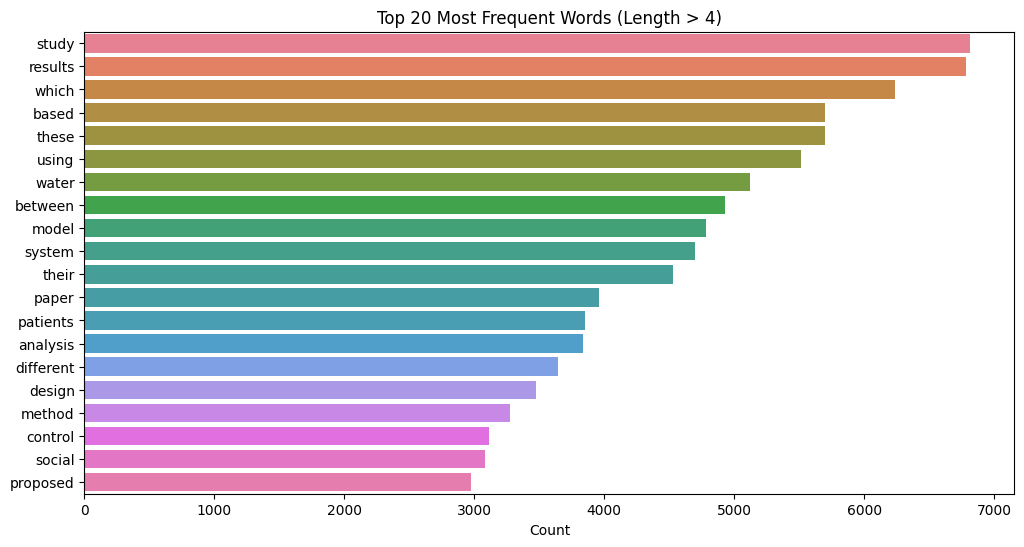

In [ ]:
def plot_top_words(texts, n=20):
    all_text = " ".join(texts).lower()
    words = re.findall(r'\w+', all_text)
    words = [w for w in words if len(w) > 4]

    word_counts = Counter(words)
    common_words = word_counts.most_common(n)

    words_list, counts_list = zip(*common_words)
    plt.figure(figsize=(12, 6))
    sns.barplot(x=list(counts_list), y=list(words_list), hue=words_list, legend=False)
    plt.title(f'Top {n} Most Frequent Words (Length > 4)')
    plt.xlabel('Count')
    plt.show()

plot_top_words(raw_texts)

## Train/Test Split

In [ ]:
train_val_texts, test_texts, train_val_l1, test_labels_l1, train_val_l2, test_labels_l2 = train_test_split(
    raw_texts,
    raw_labels_l1,
    raw_labels_l2,
    test_size=0.2,
    random_state=42,
    stratify=raw_labels_l2
)

train_texts, val_texts, train_labels_l1, val_labels_l1, train_labels_l2, val_labels_l2 = train_test_split(
    train_val_texts,
    train_val_l1,
    train_val_l2,
    test_size=0.1,
    random_state=42,
    stratify=train_val_l2
)
print(f"Train: {len(train_texts)}, Val: {len(val_texts)}, Test: {len(test_texts)}")

Train: 8615, Val: 958, Test: 2394


## Glove Embeddings

In [ ]:
#nltk.download('stopwords')
#stop_words = set(nltk.corpus.stopwords.words('english')) # only for LSTM

def tokenize_text(text):
    tokens = re.findall(r'\w+', text.lower())
    #filtered_tokens = [token for token in tokens if token not in stop_words and len(token) > 1]
    return tokens

def build_vocab(texts, max_size=10000):
    word_counts = Counter()
    for text in texts:
        tokens = tokenize_text(text)
        word_counts.update(tokens)

    vocab = {'<PAD>': 0, '<UNK>': 1}

    for word, _ in word_counts.most_common(max_size - 2):
        vocab[word] = len(vocab)

    return vocab

def load_glove_weights(vocab, glove_dir=GLOVE_PATH, embedding_dim=300):
    matrix = np.random.normal(scale=0.6, size=(len(vocab), embedding_dim))

    matrix[vocab['<PAD>']] = np.zeros(embedding_dim)

    found = 0
    with open(glove_dir, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            if word in vocab:
                vector = np.asarray(values[1:], dtype='float32')
                if len(vector) == embedding_dim:
                    found += 1
                    matrix[vocab[word]] = vector

    return torch.tensor(matrix, dtype=torch.float32)

In [ ]:
vocab = build_vocab(train_texts)
embedding_weights = load_glove_weights(vocab, GLOVE_PATH, 300)

## BERT tokenizer

In [ ]:
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

## Datasets

In [ ]:
class WOSGloveDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=256):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        tokens = tokenize_text(text)
        token_ids = [self.vocab.get(t, self.vocab['<UNK>']) for t in tokens]

        if len(token_ids) > self.max_len:
            token_ids = token_ids[:self.max_len]

        if len(token_ids) < self.max_len:
            token_ids += [self.vocab['<PAD>']] * (self.max_len - len(token_ids))

        return {
            'input_ids': torch.tensor(token_ids),
            'labels': torch.tensor(label)
        }

class WOSBertDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Task 2: Implement LSTM and BERT models

In [ ]:
import copy

class EarlyStopper:
    def __init__(self, patience=3, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.min_validation_loss = float('inf')
        self.best_model_weights = None

    def early_stop(self, validation_loss, model):
        if validation_loss < self.min_validation_loss:
            self.min_validation_loss = validation_loss
            self.counter = 0
            self.best_model_weights = copy.deepcopy(model.state_dict())
        elif validation_loss > (self.min_validation_loss + self.min_delta):
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False

    def load_best_weights(self, model):
        if self.best_model_weights is not None:
            model.load_state_dict(self.best_model_weights)
            print("Restored best model weights")

## LSTM

In [ ]:
class LSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(LSTMCell, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size

        self.W_ii = nn.Linear(input_size, hidden_size)
        self.W_if = nn.Linear(input_size, hidden_size)
        self.W_ig = nn.Linear(input_size, hidden_size)
        self.W_io = nn.Linear(input_size, hidden_size)

        self.W_hi = nn.Linear(hidden_size, hidden_size)
        self.W_hf = nn.Linear(hidden_size, hidden_size)
        self.W_hg = nn.Linear(hidden_size, hidden_size)
        self.W_ho = nn.Linear(hidden_size, hidden_size)

        self.init_weights()

    def init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x, hidden):
        h_prev, c_prev = hidden

        i_t = torch.sigmoid(self.W_ii(x) + self.W_hi(h_prev))
        f_t = torch.sigmoid(self.W_if(x) + self.W_hf(h_prev))
        g_t = torch.tanh(self.W_ig(x) + self.W_hg(h_prev))
        o_t = torch.sigmoid(self.W_io(x) + self.W_ho(h_prev))

        c_t = f_t * c_prev + i_t * g_t
        h_t = o_t * torch.tanh(c_t)

        return h_t, c_t

class LSTMModel(nn.Module):
    def __init__(
        self,
        output_dim,
        embedding_weights,
        hidden_size=64,
        freeze_embeddings=True,
    ):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size

        _, embedding_dim = embedding_weights.shape
        self.embedding = nn.Embedding.from_pretrained(
            embedding_weights,
            padding_idx=0,
            freeze=freeze_embeddings,
        )

        self.lstm_cell = LSTMCell(embedding_dim, hidden_size)
        self.fc = nn.Linear(hidden_size, output_dim)

    def forward(self, input_ids):
        embedded = self.embedding(input_ids)

        batch_size = embedded.size(0)
        seq_len = embedded.size(1)

        h_t = torch.zeros(batch_size, self.hidden_size).to(embedded.device)
        c_t = torch.zeros(batch_size, self.hidden_size).to(embedded.device)

        for t in range(seq_len):
            x_t = embedded[:, t, :]
            h_t, c_t = self.lstm_cell(x_t, (h_t, c_t))

        out = self.fc(h_t)
        return out

    def fit(self, train_loader, val_loader, epochs=10, lr=0.001, patience=3):
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(self.parameters(), lr=lr)
        early_stopper = EarlyStopper(patience=patience)
        loss_history = []

        for epoch in range(epochs):
            self.train()
            total_loss = 0
            correct = 0
            total = 0
            for batch in train_loader:
                input_ids = batch['input_ids'].to(device)
                labels = batch['labels'].to(device)

                optimizer.zero_grad()
                outputs = self.forward(input_ids)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                total_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

            epoch_loss = total_loss/len(train_loader)
            loss_history.append(epoch_loss)

            self.eval()
            val_loss = 0
            with torch.no_grad():
                for batch in val_loader:
                    input_ids = batch['input_ids'].to(device)
                    labels = batch['labels'].to(device)
                    outputs = self.forward(input_ids)
                    loss = criterion(outputs, labels)
                    val_loss += loss.item()

            avg_val_loss = val_loss / len(val_loader)

            print(f"LSTM Epoch {epoch+1}/{epochs}, Train Loss: {epoch_loss:.4f}, Validation Loss: {avg_val_loss:.4f}, Acc: {correct/total:.4f}")

            if early_stopper.early_stop(avg_val_loss, self):
                print(f"Early stopping at epoch {epoch+1}")
                early_stopper.load_best_weights(self)
                break

        if early_stopper.best_model_weights:
            early_stopper.load_best_weights(self)

        return loss_history

    def predict(self, loader):
        self.eval()
        predictions = []
        with torch.no_grad():
            for batch in loader:
                input_ids = batch['input_ids'].to(device)
                outputs = self.forward(input_ids)
                _, predicted = torch.max(outputs.data, 1)
                predictions.extend(predicted.cpu().numpy())
        return np.array(predictions)

    def evaluate_acc(self, y_true, y_pred):
        y_true = np.array(y_true)
        y_pred = np.array(y_pred)
        return np.mean(y_true == y_pred)

## BERT

In [ ]:
def train_bert(model, train_loader, val_loader, epochs=3, patience=2):
    optimizer = optim.AdamW(model.parameters(), lr=2e-5)
    early_stopper = EarlyStopper(patience=patience)
    loss_history = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        correct = 0
        total = 0
        for batch in train_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(outputs.logits, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        avg_train_loss = total_loss/len(train_loader)
        loss_history.append(avg_train_loss)

        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
                val_loss += outputs.loss.item()

                _, predicted = torch.max(outputs.logits, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        avg_val_loss = val_loss / len(val_loader)
        val_acc = val_correct / val_total

        print(f"BERT Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Validation Loss: {avg_val_loss:.4f}, Acc: {correct/total:.4f}, Val Acc: {val_acc:.4f}")

        if early_stopper.early_stop(avg_val_loss, model):
            print(f"Early stopping at epoch {epoch+1}")
            early_stopper.load_best_weights(model)
            break

    if early_stopper.best_model_weights:
        early_stopper.load_best_weights(model)

    return loss_history

def evaluate_bert(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            _, predicted = torch.max(outputs.logits, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total

# Task 3: Run experiments

## L1 Data Preparation

In [ ]:
train_dataset_lstm_l1 = WOSGloveDataset(train_texts, train_labels_l1, vocab)
val_dataset_lstm_l1 = WOSGloveDataset(val_texts, val_labels_l1, vocab)
test_dataset_lstm_l1 = WOSGloveDataset(test_texts, test_labels_l1, vocab)

train_loader_lstm_l1 = DataLoader(train_dataset_lstm_l1, batch_size=32, shuffle=True)
val_loader_lstm_l1 = DataLoader(val_dataset_lstm_l1, batch_size=32, shuffle=False)
test_loader_lstm_l1 = DataLoader(test_dataset_lstm_l1, batch_size=32, shuffle=False)

train_dataset_bert_l1 = WOSBertDataset(train_texts, train_labels_l1, bert_tokenizer)
val_dataset_bert_l1 = WOSBertDataset(val_texts, val_labels_l1, bert_tokenizer)
test_dataset_bert_l1 = WOSBertDataset(test_texts, test_labels_l1, bert_tokenizer)

train_loader_bert_l1 = DataLoader(train_dataset_bert_l1, batch_size=16, shuffle=True)
val_loader_bert_l1 = DataLoader(val_dataset_bert_l1, batch_size=16, shuffle=False)
test_loader_bert_l1 = DataLoader(test_dataset_bert_l1, batch_size=16, shuffle=False)

TRAIN_EPOCHS = 50

## L1 Train LSTM

In [ ]:
lstm_model_l1 = LSTMModel(output_dim=7, embedding_weights=embedding_weights, hidden_size=128).to(device)
lstm_l1_loss_history = lstm_model_l1.fit(train_loader_lstm_l1, val_loader_lstm_l1, epochs=TRAIN_EPOCHS, patience=5)

lstm_preds_l1 = lstm_model_l1.predict(test_loader_lstm_l1)
lstm_acc_l1 = lstm_model_l1.evaluate_acc(test_labels_l1, lstm_preds_l1)
print(f"LSTM Level 1 Test Accuracy: {lstm_acc_l1:.4f}")

LSTM Epoch 1/50, Train Loss: 1.8171, Validation Loss: 1.9196, Acc: 0.2441
LSTM Epoch 2/50, Train Loss: 1.6405, Validation Loss: 1.4732, Acc: 0.3112
LSTM Epoch 3/50, Train Loss: 1.5353, Validation Loss: 1.4261, Acc: 0.3796
LSTM Epoch 4/50, Train Loss: 1.5666, Validation Loss: 1.5075, Acc: 0.3601
LSTM Epoch 5/50, Train Loss: 1.5894, Validation Loss: 1.8913, Acc: 0.3442
LSTM Epoch 6/50, Train Loss: 1.7934, Validation Loss: 1.8661, Acc: 0.2751
LSTM Epoch 7/50, Train Loss: 1.5424, Validation Loss: 1.6610, Acc: 0.3625
LSTM Epoch 8/50, Train Loss: 1.3763, Validation Loss: 1.3387, Acc: 0.3920
LSTM Epoch 9/50, Train Loss: 1.2578, Validation Loss: 1.2271, Acc: 0.4613
LSTM Epoch 10/50, Train Loss: 1.1243, Validation Loss: 1.0682, Acc: 0.5663
LSTM Epoch 11/50, Train Loss: 1.0329, Validation Loss: 1.1288, Acc: 0.6123
LSTM Epoch 12/50, Train Loss: 0.9048, Validation Loss: 0.8616, Acc: 0.6753
LSTM Epoch 13/50, Train Loss: 0.7539, Validation Loss: 0.7428, Acc: 0.7407
LSTM Epoch 14/50, Train Loss: 0.57

## L1 Train BERT

In [ ]:
bert_model_l1 = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=7, output_attentions=True).to(device)
bert_l1_loss_history = train_bert(bert_model_l1, train_loader_bert_l1, val_loader_bert_l1, epochs=TRAIN_EPOCHS, patience=3)
bert_acc_l1 = evaluate_bert(bert_model_l1, test_loader_bert_l1)
print(f"BERT Level 1 Test Accuracy: {bert_acc_l1:.4f}")

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

c:\Users\Samy\Desktop\McGill\FALL 2025\COMP 551\A4\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Samy\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at 

BERT Epoch 1/50, Train Loss: 0.5954, Validation Loss: 0.3242, Acc: 0.8129, Val Acc: 0.9019
BERT Epoch 2/50, Train Loss: 0.2058, Validation Loss: 0.2969, Acc: 0.9392, Val Acc: 0.9165
BERT Epoch 3/50, Train Loss: 0.1210, Validation Loss: 0.3288, Acc: 0.9665, Val Acc: 0.9134
BERT Epoch 4/50, Train Loss: 0.0869, Validation Loss: 0.3294, Acc: 0.9760, Val Acc: 0.9134
BERT Epoch 5/50, Train Loss: 0.0565, Validation Loss: 0.3437, Acc: 0.9862, Val Acc: 0.9228
Early stopping at epoch 5
Restored best model weights
Restored best model weights
BERT Level 1 Test Accuracy: 0.9361


## L2 Data Preparation

In [ ]:
train_dataset_lstm_l2 = WOSGloveDataset(train_texts, train_labels_l2, vocab)
val_dataset_lstm_l2 = WOSGloveDataset(val_texts, val_labels_l2, vocab)
test_dataset_lstm_l2 = WOSGloveDataset(test_texts, test_labels_l2, vocab)

train_loader_lstm_l2 = DataLoader(train_dataset_lstm_l2, batch_size=32, shuffle=True)
val_loader_lstm_l2 = DataLoader(val_dataset_lstm_l2, batch_size=32, shuffle=False)
test_loader_lstm_l2 = DataLoader(test_dataset_lstm_l2, batch_size=32, shuffle=False)

train_dataset_bert_l2 = WOSBertDataset(train_texts, train_labels_l2, bert_tokenizer)
val_dataset_bert_l2 = WOSBertDataset(val_texts, val_labels_l2, bert_tokenizer)
test_dataset_bert_l2 = WOSBertDataset(test_texts, test_labels_l2, bert_tokenizer)

train_loader_bert_l2 = DataLoader(train_dataset_bert_l2, batch_size=16, shuffle=True)
val_loader_bert_l2 = DataLoader(val_dataset_bert_l2, batch_size=16, shuffle=False)
test_loader_bert_l2 = DataLoader(test_dataset_bert_l2, batch_size=16, shuffle=False)

## L2 Train LSTM

In [ ]:
lstm_model_l2 = LSTMModel(output_dim=OUTPUT_DIM_L2, embedding_weights=embedding_weights, hidden_size=128).to(device)
lstm_l2_loss_history = lstm_model_l2.fit(train_loader_lstm_l2, val_loader_lstm_l2, epochs=TRAIN_EPOCHS, patience=5)

lstm_preds_l2 = lstm_model_l2.predict(test_loader_lstm_l2)
lstm_acc_l2 = lstm_model_l2.evaluate_acc(test_labels_l2, lstm_preds_l2)
print(f"LSTM Level 2 Test Accuracy: {lstm_acc_l2:.4f}")

LSTM Epoch 1/50, Train Loss: 3.4017, Validation Loss: 3.3304, Acc: 0.0537
LSTM Epoch 2/50, Train Loss: 3.2734, Validation Loss: 3.2494, Acc: 0.0768
LSTM Epoch 3/50, Train Loss: 3.1949, Validation Loss: 3.0358, Acc: 0.0846
LSTM Epoch 4/50, Train Loss: 2.9431, Validation Loss: 2.8829, Acc: 0.1103
LSTM Epoch 5/50, Train Loss: 2.9974, Validation Loss: 3.1734, Acc: 0.1233
LSTM Epoch 6/50, Train Loss: 2.9937, Validation Loss: 2.8681, Acc: 0.1257
LSTM Epoch 7/50, Train Loss: 2.7977, Validation Loss: 2.7973, Acc: 0.1565
LSTM Epoch 8/50, Train Loss: 2.5734, Validation Loss: 2.5410, Acc: 0.1943
LSTM Epoch 9/50, Train Loss: 2.4169, Validation Loss: 2.4209, Acc: 0.2324
LSTM Epoch 10/50, Train Loss: 2.2784, Validation Loss: 2.2927, Acc: 0.2687
LSTM Epoch 11/50, Train Loss: 2.1680, Validation Loss: 2.1880, Acc: 0.3015
LSTM Epoch 12/50, Train Loss: 2.0181, Validation Loss: 2.0551, Acc: 0.3499
LSTM Epoch 13/50, Train Loss: 1.8907, Validation Loss: 2.0172, Acc: 0.3808
LSTM Epoch 14/50, Train Loss: 1.78

## L2 Train BERT

In [ ]:
bert_model_l2 = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=OUTPUT_DIM_L2, output_attentions=True).to(device)
bert_l2_loss_history = train_bert(bert_model_l2, train_loader_bert_l2, val_loader_bert_l2, epochs=TRAIN_EPOCHS)
bert_acc_l2 = evaluate_bert(bert_model_l2, test_loader_bert_l2)
print(f"BERT Level 2 Test Accuracy: {bert_acc_l2:.4f}")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BERT Epoch 1/50, Train Loss: 1.8858, Validation Loss: 0.8484, Acc: 0.5755, Val Acc: 0.8215
BERT Epoch 2/50, Train Loss: 0.6253, Validation Loss: 0.6383, Acc: 0.8649, Val Acc: 0.8299
BERT Epoch 3/50, Train Loss: 0.3878, Validation Loss: 0.6044, Acc: 0.9068, Val Acc: 0.8403
BERT Epoch 4/50, Train Loss: 0.2561, Validation Loss: 0.6028, Acc: 0.9399, Val Acc: 0.8466
BERT Epoch 5/50, Train Loss: 0.1685, Validation Loss: 0.6416, Acc: 0.9638, Val Acc: 0.8445
BERT Epoch 6/50, Train Loss: 0.1220, Validation Loss: 0.6397, Acc: 0.9709, Val Acc: 0.8476
Early stopping at epoch 6
Restored best model weights
Restored best model weights
BERT Level 2 Test Accuracy: 0.8755


## Results Summary

In [ ]:
results = pd.DataFrame({
    'Task': ['Level 1 (7 classes)', 'Level 1 (7 classes)', 'Level 2 (33 classes)', 'Level 2 (33 classes)'],
    'Model': ['LSTM', 'BERT', 'LSTM', 'BERT'],
    'Accuracy': [lstm_acc_l1, bert_acc_l1, lstm_acc_l2, bert_acc_l2]
})
print(results)
results

                   Task Model  Accuracy
0   Level 1 (7 classes)  LSTM  0.885965
1   Level 1 (7 classes)  BERT  0.936090
2  Level 2 (33 classes)  LSTM  0.749791
3  Level 2 (33 classes)  BERT  0.875522


,Task,Model,Accuracy
0,Level 1 (7 classes),LSTM,0.885965
1,Level 1 (7 classes),BERT,0.936090
2,Level 2 (33 classes),LSTM,0.749791
3,Level 2 (33 classes),BERT,0.875522


## Training Loss Visualization

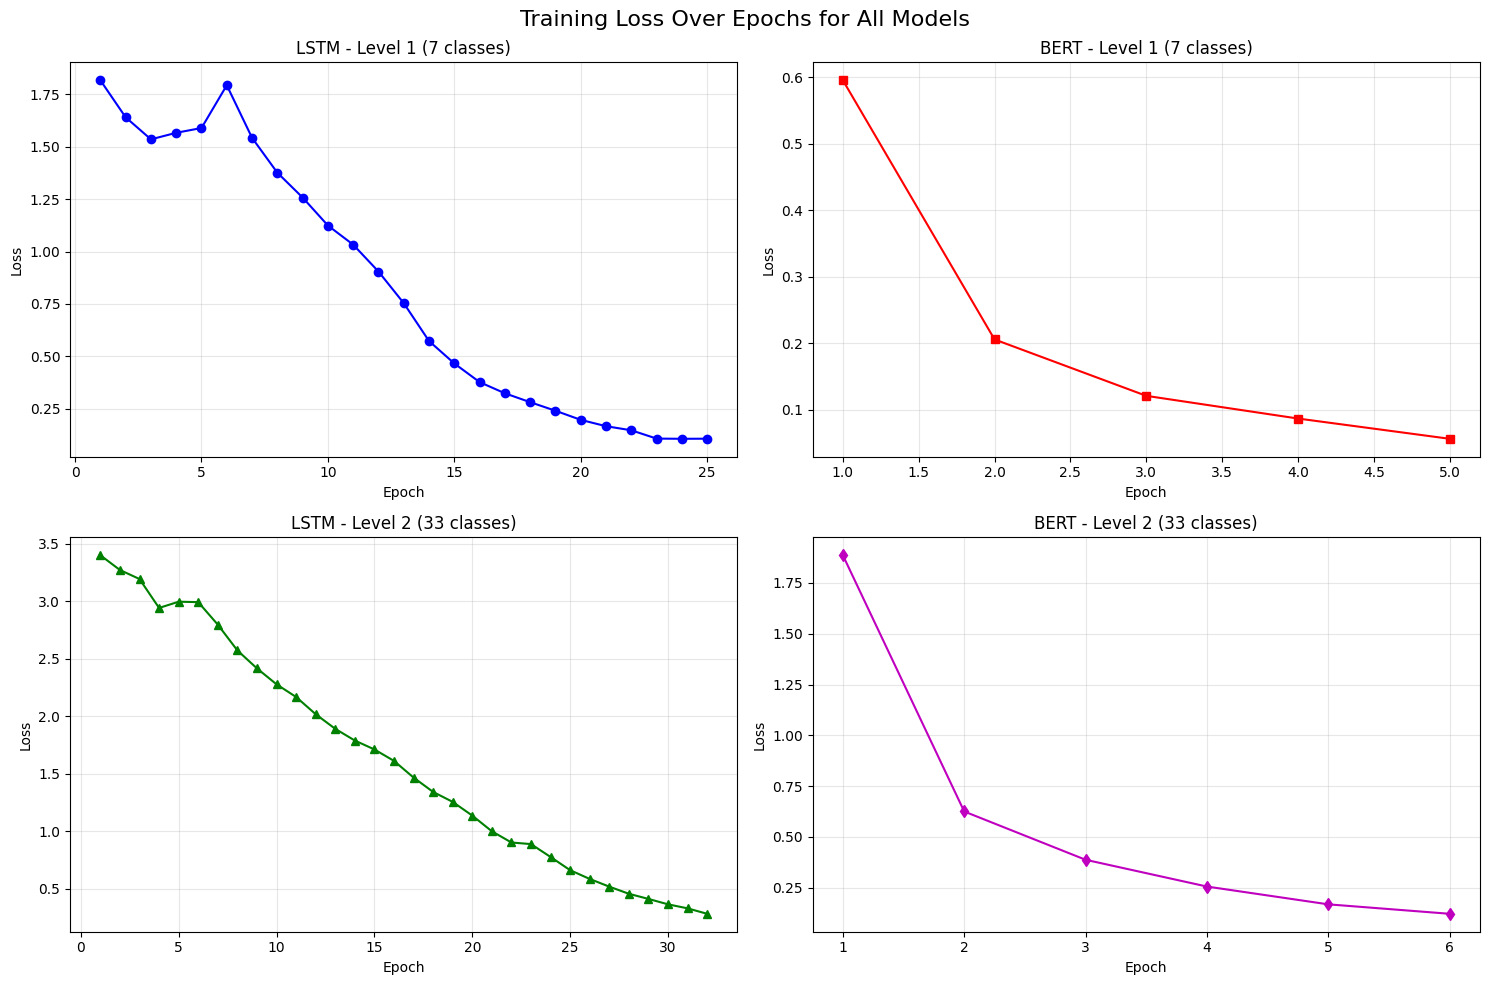

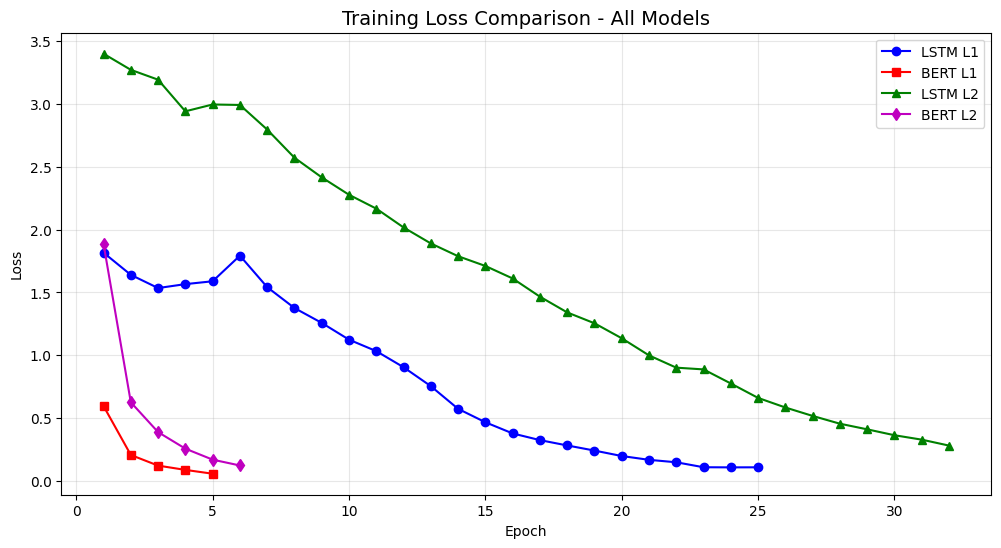

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Training Loss Over Epochs for All Models', fontsize=16)

axes[0, 0].plot(range(1, len(lstm_l1_loss_history) + 1), lstm_l1_loss_history, 'b-', marker='o')
axes[0, 0].set_title('LSTM - Level 1 (7 classes)')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(range(1, len(bert_l1_loss_history) + 1), bert_l1_loss_history, 'r-', marker='s')
axes[0, 1].set_title('BERT - Level 1 (7 classes)')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(range(1, len(lstm_l2_loss_history) + 1), lstm_l2_loss_history, 'g-', marker='^')
axes[1, 0].set_title('LSTM - Level 2 (33 classes)')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(range(1, len(bert_l2_loss_history) + 1), bert_l2_loss_history, 'm-', marker='d')
axes[1, 1].set_title('BERT - Level 2 (33 classes)')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'training_loss_all_models.png'), dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(range(1, len(lstm_l1_loss_history) + 1), lstm_l1_loss_history, 'b-', marker='o', label='LSTM L1')
plt.plot(range(1, len(bert_l1_loss_history) + 1), bert_l1_loss_history, 'r-', marker='s', label='BERT L1')
plt.plot(range(1, len(lstm_l2_loss_history) + 1), lstm_l2_loss_history, 'g-', marker='^', label='LSTM L2')
plt.plot(range(1, len(bert_l2_loss_history) + 1), bert_l2_loss_history, 'm-', marker='d', label='BERT L2')
plt.title('Training Loss Comparison - All Models', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(FIGURES_DIR, 'training_loss_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

## Attention Matrix Visualization

In [ ]:
def visualize_attention(model, tokenizer, text, label, title_prefix="", layer_idx=-1, head_idx=0):
    model.eval()
    inputs = tokenizer.encode_plus(
        text,
        return_tensors='pt',
        add_special_tokens=True,
        max_length=128,
        truncation=True,
        padding='max_length'
    ).to(device)
    input_ids = inputs['input_ids']

    with torch.no_grad():
        outputs = model(input_ids)
        attentions = outputs.attentions

    # Get attention from specific layer (shape: [batch, num_heads, seq_len, seq_len])
    layer_attn = attentions[layer_idx].squeeze(0).cpu().numpy()

    specific_head_attn = layer_attn[head_idx, :, :]

    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

    non_pad_length = len(tokens)
    for i in range(len(tokens)-1, -1, -1):
        if tokens[i] != '[PAD]':
            non_pad_length = i + 1
            break

    max_tokens = min(non_pad_length, 50)
    tokens_display = tokens[:max_tokens]
    attn_display = specific_head_attn[:max_tokens, :max_tokens]

    plt.figure(figsize=(16, 12))
    ax = sns.heatmap(
        attn_display,
        xticklabels=tokens_display,
        yticklabels=tokens_display,
        cmap='viridis',
        cbar_kws={'label': 'Attention Weight'},
        square=True
    )

    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(rotation=0, fontsize=10)

    actual_layer = layer_idx if layer_idx >= 0 else len(attentions) + layer_idx
    plt.title(f"{title_prefix}BERT Attention Map (Layer {actual_layer + 1}, Head {head_idx + 1})\nLabel: {label}", fontsize=14, pad=20)
    plt.xlabel('Key Tokens', fontsize=12)
    plt.ylabel('Query Tokens', fontsize=12)

    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, f'{title_prefix.strip().replace(" ", "_").lower()}attention_layer{actual_layer + 1}_head{head_idx + 1}.png'), dpi=300, bbox_inches='tight')
    plt.show()

--- Visualizing Level 1 Examples ---
Found INCORRECT Example at Index 0
True: 2, Pred: 0


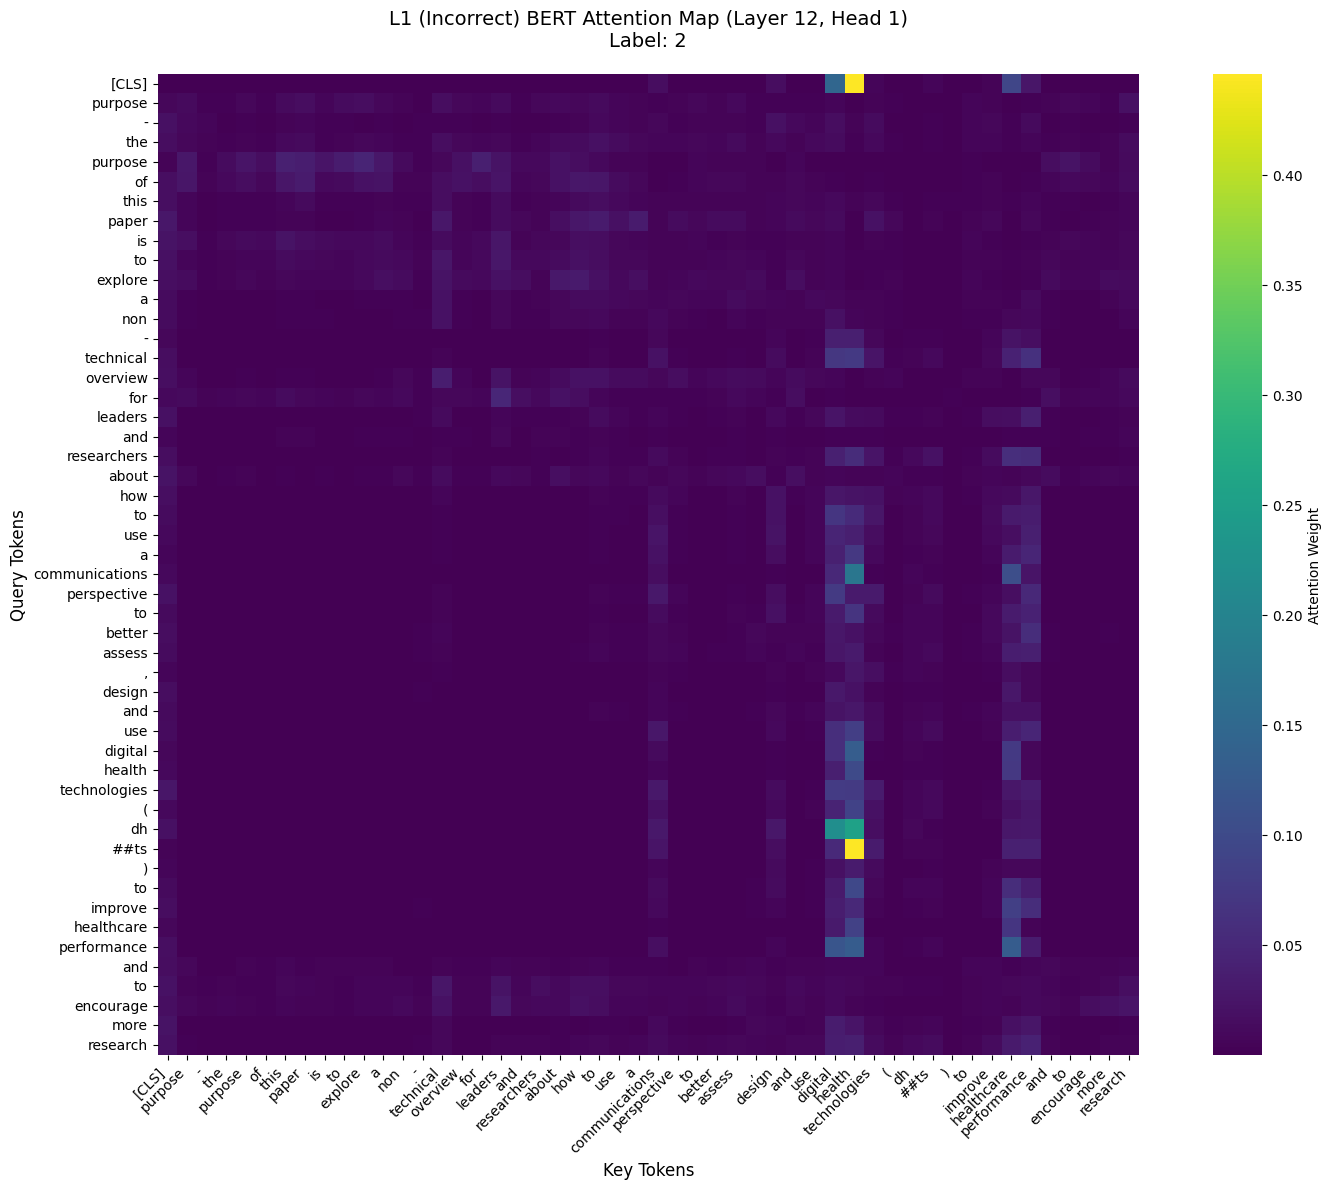

Found CORRECT Example at Index 1
True: 6, Pred: 6


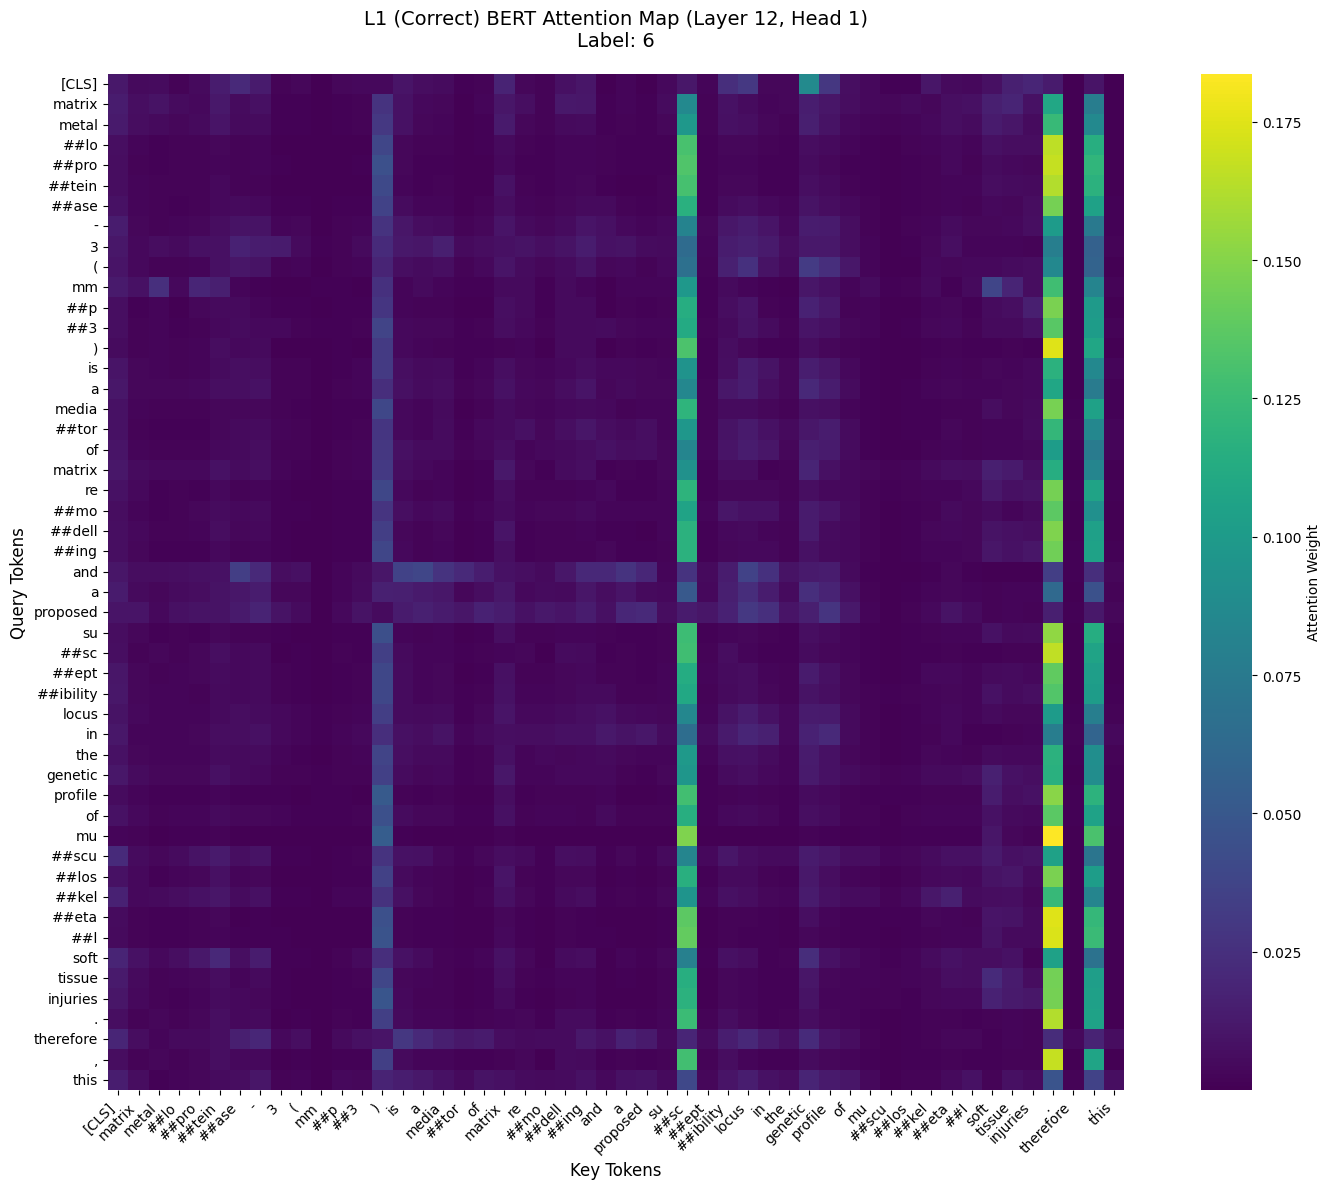

In [ ]:
def find_and_visualize_examples(model, loader, raw_texts, raw_labels, title_prefix):
    model.eval()
    found_correct = False
    found_incorrect = False

    # Iterate through the test set to find examples
    current_idx = 0
    with torch.no_grad():
        for batch in loader:
            if found_correct and found_incorrect:
                break

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            _, preds = torch.max(outputs.logits, 1)

            # Check batch results
            for i in range(len(preds)):
                is_correct = (preds[i] == labels[i]).item()
                global_idx = current_idx + i

                # Visualize Correct Example
                if is_correct and not found_correct:
                    print(f"Found CORRECT Example at Index {global_idx}")
                    print(f"True: {labels[i].item()}, Pred: {preds[i].item()}")
                    visualize_attention(
                        model, bert_tokenizer,
                        raw_texts[global_idx], raw_labels[global_idx],
                        title_prefix=f"{title_prefix} (Correct) ",
                        layer_idx=-1, head_idx=0
                    )
                    found_correct = True

                # Visualize Incorrect Example
                elif not is_correct and not found_incorrect:
                    print(f"Found INCORRECT Example at Index {global_idx}")
                    print(f"True: {labels[i].item()}, Pred: {preds[i].item()}")
                    visualize_attention(
                        model, bert_tokenizer,
                        raw_texts[global_idx], raw_labels[global_idx],
                        title_prefix=f"{title_prefix} (Incorrect) ",
                        layer_idx=-1, head_idx=0
                    )
                    found_incorrect = True

            current_idx += len(preds)


print("--- Visualizing Level 1 Examples ---")
find_and_visualize_examples(
    bert_model_l1,
    test_loader_bert_l1,
    test_texts,
    test_labels_l1,
    "L1"
)

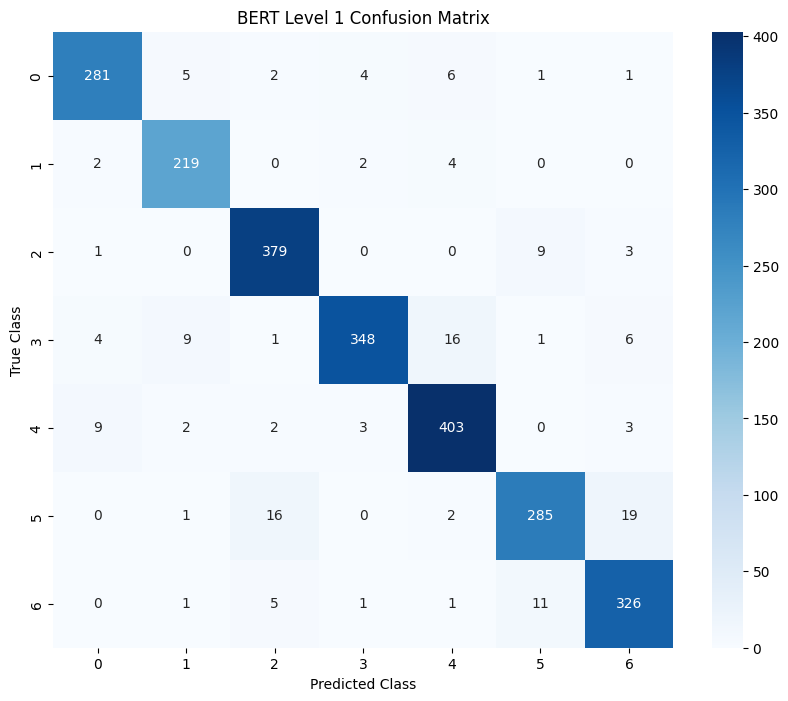

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix(model, loader, title):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)

            if 'attention_mask' in batch:
                # BERT Logic
                attention_mask = batch['attention_mask'].to(device)
                outputs = model(input_ids, attention_mask=attention_mask)
                logits = outputs.logits
            else:
                # LSTM Logic
                outputs = model(input_ids)
                logits = outputs

            _, preds = torch.max(logits, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Plotting
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel('Predicted Class')
    plt.ylabel('True Class')
    plt.show()

plot_confusion_matrix(bert_model_l1, test_loader_bert_l1, "BERT Level 1 Confusion Matrix")